<a href="https://colab.research.google.com/github/liondhindsa666-svg/SUMMER-TRAINING-2026/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

# Set seed for reproducibility
np.random.seed(42)
n_samples = 200

# Generate synthetic data
data = {
    'Customer_ID': range(1001, 1001 + n_samples),
    'Age': np.random.choice([22, 28, 35, 45, 50, 62, np.nan], size=n_samples, p=[0.2, 0.2, 0.2, 0.15, 0.15, 0.05, 0.05]),
    'Gender': np.random.choice(['Male', 'Female', 'Unknown'], size=n_samples, p=[0.45, 0.45, 0.10]),
    'Annual_Income_k$': np.random.normal(loc=65, scale=15, size=n_samples).round(1),
    'Total_Spend_$': np.random.normal(loc=400, scale=150, size=n_samples).round(2),
    'Membership_Tier': np.random.choice(['Bronze', 'Silver', 'Gold'], size=n_samples, p=[0.5, 0.3, 0.2]),
    'Satisfied': np.random.choice(['Yes', 'No'], size=n_samples, p=[0.7, 0.3])
}

df = pd.DataFrame(data)

# Injecting artificial Outliers into 'Total_Spend_$'
df.loc[15, 'Total_Spend_$'] = 2500.00  # Extreme high outlier
df.loc[87, 'Total_Spend_$'] = -150.00   # Negative value outlier
df.loc[142, 'Total_Spend_$'] = 3100.00  # Extreme high outlier

# Save to CSV
df.to_csv('ecommerce_customer_data.csv', index=False)
print("Dataset 'ecommerce_customer_data.csv' successfully generated!")

Dataset 'ecommerce_customer_data.csv' successfully generated!


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('ecommerce_customer_data.csv')

# 1. Print data dimensions and column data types
print(df.info())

# 2. Check for missing values explicitly
print("\nMissing Values Count:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Customer_ID       200 non-null    int64  
 1   Age               192 non-null    float64
 2   Gender            200 non-null    object 
 3   Annual_Income_k$  200 non-null    float64
 4   Total_Spend_$     200 non-null    float64
 5   Membership_Tier   200 non-null    object 
 6   Satisfied         200 non-null    object 
dtypes: float64(3), int64(1), object(3)
memory usage: 11.1+ KB
None

Missing Values Count:
 Customer_ID         0
Age                 8
Gender              0
Annual_Income_k$    0
Total_Spend_$       0
Membership_Tier     0
Satisfied           0
dtype: int64


In [3]:
# 1. Impute missing 'Age' values using direct assignment (avoids Chained Assignment warning)
age_median = df['Age'].median()
df['Age'] = df['Age'].fillna(age_median)

# 2. Replace 'Unknown' in Gender with the mode (most frequent value)
gender_mode = df['Gender'].mode()[0]
df['Gender'] = df['Gender'].replace('Unknown', gender_mode)

# Verify the changes worked
print("Missing values after cleaning:\n", df[['Age', 'Gender']].isnull().sum())
print("\nUnique values in Gender now:", df['Gender'].unique())

Missing values after cleaning:
 Age       0
Gender    0
dtype: int64

Unique values in Gender now: ['Female' 'Male']


In [4]:
# Calculate IQR for Total_Spend_$
Q1 = df['Total_Spend_$'].quantile(0.25)
Q3 = df['Total_Spend_$'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out the outliers
outliers = df[(df['Total_Spend_$'] < lower_bound) | (df['Total_Spend_$'] > upper_bound)]
print(f"Detected {len(outliers)} outliers.")

# Keep only valid data
#df_clean = df[(df['Total_Spend_$'] >= lower_bound) & (df['Total_Spend_$'] <= upper_bound)]
# Keep only valid data and explicitly break the link to the original df
df_clean = df[(df['Total_Spend_$'] >= lower_bound) & (df['Total_Spend_$'] <= upper_bound)].copy()

Detected 5 outliers.


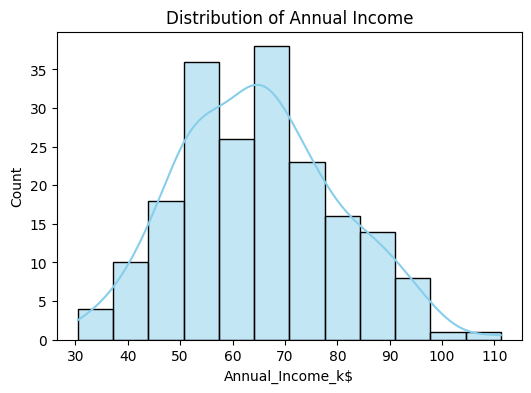

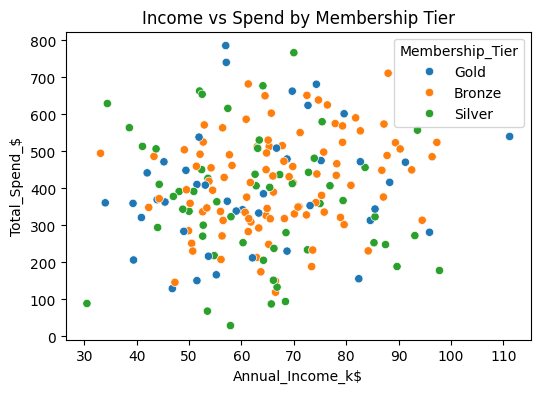

In [5]:
# Univariate: Plot the distribution of Annual Income
plt.figure(figsize=(6,4))
sns.histplot(df_clean['Annual_Income_k$'], kde=True, color='skyblue')
plt.title('Distribution of Annual Income')
plt.show()

# Bivariate: Relationship between Annual Income and Total Spend
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean, x='Annual_Income_k$', y='Total_Spend_$', hue='Membership_Tier')
plt.title('Income vs Spend by Membership Tier')
plt.show()